In [ ]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from google.colab import drive

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AIML/Data/Copy of devnagari digit.zip'
data_path = '/content/drive/MyDrive/AIML/Data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AIML/Data/Copy of devnagari digit.zip' to '/content/drive/MyDrive/AIML'


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img_height, img_width = 28, 28
num_classes=10

In [ ]:
train_dir = '/content/drive/MyDrive/AIML/DevanagariHandwrittenDigitDataset/Train'
test_dir = '/content/drive/MyDrive/AIML/DevanagariHandwrittenDigitDataset/Test'

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


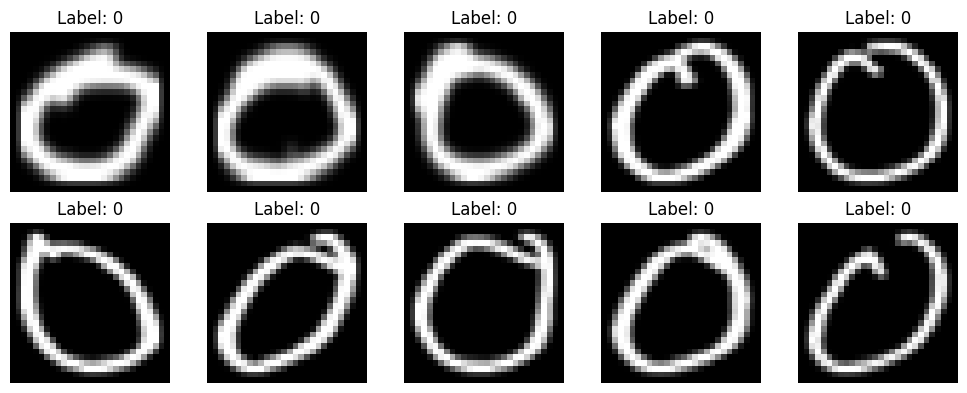

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import to_categorical
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print shapes
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualization
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


# Task 4: Train the Model

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_devnagari_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2996 - loss: 1.9713
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.h5



Epoch 1: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5049 - loss: 1.5975 - val_accuracy: 0.0000e+00 - val_loss: 7.4214
Epoch 2/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8179 - loss: 0.6020
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8401 - loss: 0.4851 - val_accuracy: 0.0000e+00 - val_loss: 8.7663
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9093 - loss: 0.3034
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9193 - loss: 0.2738 - val_accuracy: 0.0000e+00 - val_loss: 9.1962
Epoch 4/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9458 - loss: 0.1951
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9474 - loss: 0.1868 - val_accuracy: 0.0000e+00 - val_loss: 9.5732
Epoch 5/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 

# Task 5: Evaluate the Model

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

94/94 - 0s - 3ms/step - accuracy: 0.6170 - loss: 2.1007
Test Loss: 2.1006855964660645
Test Accuracy: 0.6169999837875366


# Task 6: Save the Model

In [15]:
model.save('devnagari_fcn_model.h5')
print("Model saved successfully")

Model saved successfully


Task 6: Load the Model and Evaluate Again

In [16]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print("Loaded Model Loss:", loaded_loss)
print("Loaded Model Accuracy:", loaded_acc)

Model loaded successfully
94/94 - 1s - 8ms/step - accuracy: 0.6170 - loss: 2.1007
Loaded Model Loss: 2.1006855964660645
Loaded Model Accuracy: 0.6169999837875366


# Task 7: Make Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
First 10 Predictions:
Image 1: Predicted = 0, True = 0
Image 2: Predicted = 0, True = 0
Image 3: Predicted = 0, True = 0
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 0, True = 0
Image 6: Predicted = 0, True = 0
Image 7: Predicted = 0, True = 0
Image 8: Predicted = 0, True = 0
Image 9: Predicted = 0, True = 0
Image 10: Predicted = 0, True = 0


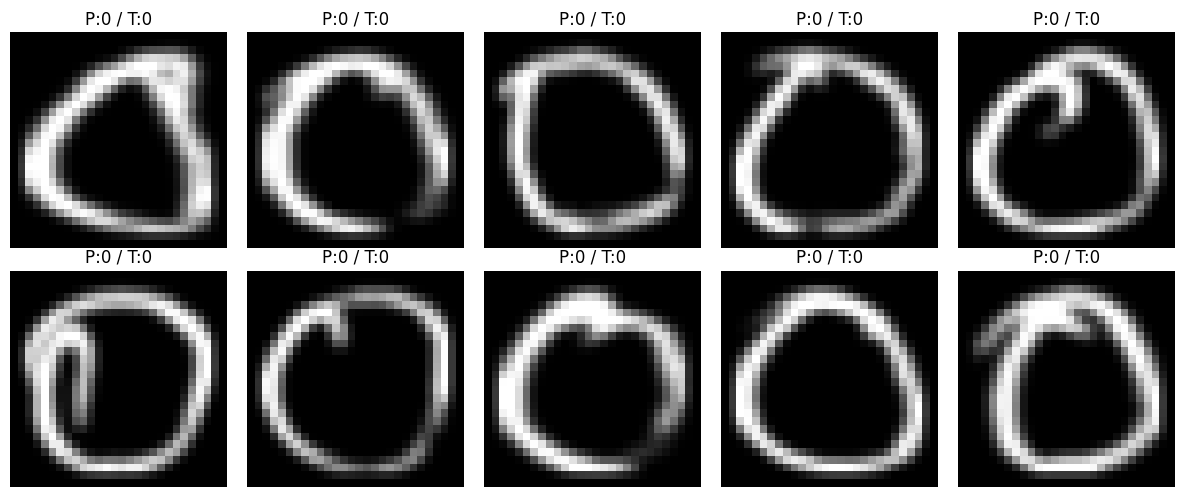

In [17]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("First 10 Predictions:")
for i in range(10):
    print(f"Image {i+1}: Predicted = {predicted_labels[i]}, True = {true_labels[i]}")

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()